In [1]:
import jax
import jax.numpy as jnp
import netket as nk
import netket.experimental as nkx
import numpy as np
from pyscf import gto, scf, fci
from flax import linen as nn
import flax.nnx as nnx
import optax
from tqdm import tqdm
from functools import partial
from jax import flatten_util
import matplotlib.pyplot as plt


# ==============================================================================
# 1. 全局参数 & H₂ 分子定义
# ==============================================================================
bond_length = 1.4
geometry = [('H', (0., 0., 0.)), ('H', (bond_length, 0., 0.))]
mol = gto.M(atom=geometry, basis='STO-3G', verbose=0)
mf = scf.RHF(mol).run(verbose=0)

cisolver = fci.FCI(mf)
cisolver.nroots = 4
E_fcis, fcivec = cisolver.kernel()
print("="*60)
print("H₂ FCI 基准能量")
print("="*60)
for i, e in enumerate(E_fcis):
    exc = (e - E_fcis[0]) * 27.2114
    print(f"E{i} = {e:.8f} Ha  |  激发能: {exc:.4f} eV")

ha = nkx.operator.from_pyscf_molecule(mol)
hi = nk.hilbert.SpinOrbitalFermions(
    n_orbitals=2,
    s=1/2,
    n_fermions_per_spin=(1,1),
)

# ==============================================================================
# 2. 神经网络 Ansatz 
# ==============================================================================
class SingleStateAnsatz(nnx.Module):
    def __init__(self, n_spin_orbitals: int, hidden_dim=16, *, rngs: nnx.Rngs):
        super().__init__()
        self.linear1 = nnx.Linear(n_spin_orbitals, hidden_dim, rngs=rngs, param_dtype=complex)
        self.linear2 = nnx.Linear(hidden_dim, hidden_dim, rngs=rngs, param_dtype=complex)
        self.output = nnx.Linear(hidden_dim, 1, rngs=rngs, param_dtype=complex)

    def __call__(self, x):
        h = nnx.tanh(self.linear1(x.astype(complex)))
        h = nnx.tanh(self.linear2(h))
        out = self.output(h)
        return jnp.squeeze(out)

# ==============================================================================
# 3. 初始化模型、采样器、优化器
# ==============================================================================
edges = [(0, 1), (2, 3)]
g = nk.graph.Graph(edges=edges)
single_rule = nk.sampler.rules.FermionHopRule(hilbert=hi, graph=g)
sampler = nk.sampler.MetropolisSampler(hi, rule=single_rule, n_chains=100, sweep_size=32)

/opt/miniconda3/envs/Neural/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


H₂ FCI 基准能量
E0 = -1.01546825 Ha  |  激发能: 0.0000 eV
E1 = -0.87542794 Ha  |  激发能: 3.8107 eV
E2 = -0.42938376 Ha  |  激发能: 15.9482 eV
E3 = -0.26922131 Ha  |  激发能: 20.3064 eV


In [5]:
# ===================== 4. 包装模型为 machine 函数 =====================
def create_machine(model: nnx.Module):
    graphdef, state = nnx.split(model)
    
    @jax.jit
    def machine(params, sigma):
        m = nnx.merge(graphdef, params)
        return m(sigma)
    
    return machine, graphdef, state

# ===================== 5. 局部能量计算 =====================
@partial(jax.jit, static_argnames=("machine",))
def compute_local_energies(machine, params, sigma):
    eta, H_eta = ha.get_conn_padded(sigma)
    logpsi_sigma = machine(params, sigma)
    logpsi_eta = machine(params, eta)
    logpsi_sigma = jnp.expand_dims(logpsi_sigma, -1)
    return jnp.sum(H_eta * jnp.exp(logpsi_eta - logpsi_sigma), axis=-1)


def statistics(x):
    mean = jnp.mean(x)
    var = jnp.var(x)
    return mean, jnp.sqrt(var / x.shape[0])

# ===================== 6. Force-based 梯度计算 =====================
#@partial(jax.jit, static_argnames=("machine",))
def forces_expect_hermitian(machine, params, sigma):
    O_loc = compute_local_energies(machine, params, sigma)
    O_mean, O_std = statistics(O_loc)
    O_centered = O_loc - O_mean
    
    def log_psi_single(p, s):
        return machine(p, s)
    
    def compute_grad_for_sample(s):
        return jax.grad(lambda p: log_psi_single(p, s), holomorphic=True)(params)
    
    grad_matrix = jax.vmap(compute_grad_for_sample)(sigma)
    
    def weight_and_mean(grad_component):
        weights = O_centered.reshape((O_centered.shape[0],) + (1,) * (grad_component.ndim - 1))
        return jnp.mean(weights * jnp.conj(grad_component), axis=0)
    
    grad = jax.tree.map(weight_and_mean, grad_matrix)
    
    return O_mean, O_std, grad

# ===================== 7. QGT (量子几何张量) 计算 =====================
#@partial(jax.jit, static_argnames=("machine",))
def compute_qgt(machine, params, sigma, diag_shift=0.1):
    n_samples = sigma.shape[0]
    
    def log_psi_single(p, s):
        return machine(p, s)
    
    def compute_grad_for_sample(s):
        return jax.grad(lambda p: log_psi_single(p, s), holomorphic=True)(params)
    
    grad_matrix = jax.vmap(compute_grad_for_sample)(sigma)
    grad_flat, unravel_fn = flatten_util.ravel_pytree(grad_matrix)
    grad_flat = grad_flat.reshape(n_samples, -1)
    
    grad_mean = jnp.mean(grad_flat, axis=0, keepdims=True)
    grad_centered = grad_flat - grad_mean
    
    qgt = (1.0 / n_samples) * jnp.conj(grad_centered).T @ grad_centered
    qgt_reg = qgt + diag_shift * jnp.eye(qgt.shape[0])
    
    return qgt_reg, unravel_fn

In [6]:
# ===================== 8. 训练函数定义 =====================
def run_training(machine, params, sampler, sampler_state, optimizer, hi, 
                 use_qgt=True, diag_shift=0.001, n_iter=300, n_samples=1008):
    opt_state = optimizer.init(params)
    history = {
        'step': [],
        'energy': [],
        'energy_std': [],
        'error': []
    }
    
    for step in range(n_iter):
        sampler_state = sampler.reset(machine, params, sampler_state)
        samples, sampler_state = sampler.sample(
            machine, params, state=sampler_state, 
            chain_length=20
        )
        samples = samples.reshape(-1, hi.size)
        
        energy, energy_std, grad = forces_expect_hermitian(machine, params, samples)
        grad = jax.tree.map(lambda x: x*2, grad)
        
        if use_qgt:
            qgt_reg, qgt_unravel_fn = compute_qgt(machine, params, samples, diag_shift)
            grad_flat, grad_unravel_fn = flatten_util.ravel_pytree(grad)
            natural_grad = jnp.linalg.solve(qgt_reg, grad_flat)
            grad = grad_unravel_fn(natural_grad)
        
        updates, opt_state = optimizer.update(grad, opt_state, params)
        params = optax.apply_updates(params, updates)
        
        if step % 50 == 0 or step == n_iter - 1:
            error = jnp.abs(energy.real - E_fcis[0])
            history['step'].append(step)
            history['energy'].append(float(energy.real))
            history['energy_std'].append(float(energy_std))
            history['error'].append(float(error))
    
    return params, history


In [7]:
# ===================== 9. 运行对比实验 =====================
N_ITER = 300
N_SAMPLES = 1008
HIDDEN_DIM = 12

print("="*70)
print("对比实验：自然梯度 VMC (QGT) vs 普通梯度下降")
print("="*70)

# --- 实验 1: 使用 QGT (自然梯度) ---
print("\n" + "-"*60)
print("实验 1: 使用自然梯度 (QGT)")
print("-"*60)

rngs_qgt = nnx.Rngs(21)
model_qgt = SingleStateAnsatz(4, hidden_dim=HIDDEN_DIM, rngs=rngs_qgt)
machine_qgt, graphdef_qgt, params_qgt = create_machine(model_qgt)
sampler_state_qgt = sampler.init_state(machine_qgt, params_qgt, seed=1)
optimizer_qgt = optax.sgd(learning_rate=0.01)

params_qgt_final, history_qgt = run_training(
    machine_qgt, params_qgt, sampler, sampler_state_qgt, optimizer_qgt, hi,
    use_qgt=True, diag_shift=0.001, n_iter=N_ITER, n_samples=N_SAMPLES
)

# --- 实验 2: 不使用 QGT (普通梯度) ---
print("\n" + "-"*60)
print("实验 2: 使用普通梯度 (无 QGT)")
print("-"*60)

rngs_noqgt = nnx.Rngs(21)
model_noqgt = SingleStateAnsatz(4, hidden_dim=HIDDEN_DIM, rngs=rngs_noqgt)
machine_noqgt, graphdef_noqgt, params_noqgt = create_machine(model_noqgt)
sampler_state_noqgt = sampler.init_state(machine_noqgt, params_noqgt, seed=1)
optimizer_noqgt = optax.sgd(learning_rate=0.01)

params_noqgt_final, history_noqgt = run_training(
    machine_noqgt, params_noqgt, sampler, sampler_state_noqgt, optimizer_noqgt, hi,
    use_qgt=False, n_iter=N_ITER, n_samples=N_SAMPLES
)

对比实验：自然梯度 VMC (QGT) vs 普通梯度下降

------------------------------------------------------------
实验 1: 使用自然梯度 (QGT)
------------------------------------------------------------

------------------------------------------------------------
实验 2: 使用普通梯度 (无 QGT)
------------------------------------------------------------


In [8]:
# ===================== 10. 结果汇总 =====================
print("\n" + "="*70)
print("训练结果汇总")
print("="*70)

print("\n" + "-"*70)
print("自然梯度 (QGT) 方法:")
print("-"*70)
for i, (step, E, std, err) in enumerate(zip(
    history_qgt['step'], history_qgt['energy'], 
    history_qgt['energy_std'], history_qgt['error'])):
    print(f"Step {step:3d} | E: {E:.8f} ± {std:.6f} | Error: {err:.6f}")

print("\n" + "-"*70)
print("普通梯度方法:")
print("-"*70)
for i, (step, E, std, err) in enumerate(zip(
    history_noqgt['step'], history_noqgt['energy'], 
    history_noqgt['energy_std'], history_noqgt['error'])):
    print(f"Step {step:3d} | E: {E:.8f} ± {std:.6f} | Error: {err:.6f}")

print("\n" + "="*70)
print("最终结果对比")
print("="*70)
final_qgt = history_qgt['energy'][-1]
final_noqgt = history_noqgt['energy'][-1]
err_qgt = jnp.abs(final_qgt - E_fcis[0])
err_noqgt = jnp.abs(final_noqgt - E_fcis[0])

print(f"FCI 基准能量:      {E_fcis[0]:.8f} Ha")
print(f"-"*70)
print(f"自然梯度 (QGT):    {final_qgt:.8f} Ha  |  误差: {err_qgt:.6f} Ha ({err_qgt/jnp.abs(E_fcis[0])*100:.4f}%)")
print(f"普通梯度:          {final_noqgt:.8f} Ha  |  误差: {err_noqgt:.6f} Ha ({err_noqgt/jnp.abs(E_fcis[0])*100:.4f}%)")
print(f"-"*70)
print(f"QGT 相对提升:      {(err_noqgt - err_qgt)/err_noqgt * 100:.2f}%")


训练结果汇总

----------------------------------------------------------------------
自然梯度 (QGT) 方法:
----------------------------------------------------------------------
Step   0 | E: -0.48108884 ± 0.005743 | Error: 0.534379
Step  50 | E: -0.94973750 ± 0.006444 | Error: 0.065731
Step 100 | E: -0.96152565 ± 0.004666 | Error: 0.053943
Step 150 | E: -0.96894767 ± 0.002735 | Error: 0.046521
Step 200 | E: -1.00163073 ± 0.001210 | Error: 0.013838
Step 250 | E: -1.01172069 ± 0.000656 | Error: 0.003748
Step 299 | E: -1.01303152 ± 0.000762 | Error: 0.002437

----------------------------------------------------------------------
普通梯度方法:
----------------------------------------------------------------------
Step   0 | E: -0.48108884 ± 0.005743 | Error: 0.534379
Step  50 | E: -0.85658073 ± 0.002598 | Error: 0.158888
Step 100 | E: -0.86779528 ± 0.001922 | Error: 0.147673
Step 150 | E: -0.87313628 ± 0.001306 | Error: 0.142332
Step 200 | E: -0.87652757 ± 0.000749 | Error: 0.138941
Step 250 | E: -0.876746

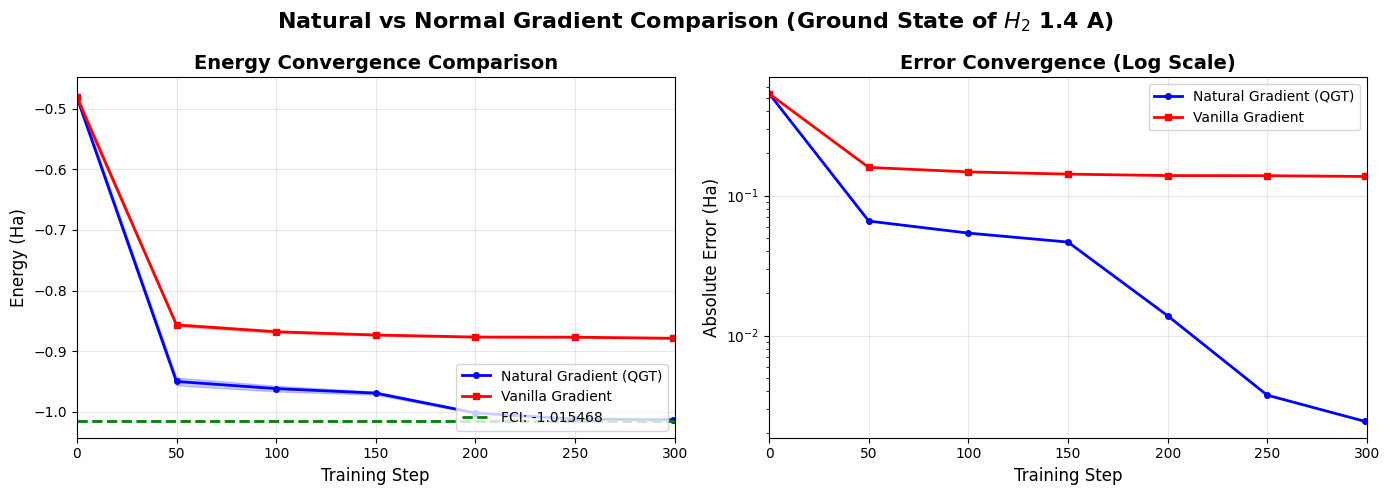


图表已保存为 'qgt_comparison.png'


In [12]:
# ===================== 11. 可视化对比 =====================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

fig.suptitle('Natural vs Normal Gradient Comparison (Ground State of $H_2$ 1.4 A)', fontsize=16, fontweight='bold')
# 子图 1: 能量收敛对比
ax1 = axes[0]
ax1.plot(history_qgt['step'], history_qgt['energy'], 'b-', linewidth=2, label='Natural Gradient (QGT)', marker='o', markersize=4)
ax1.plot(history_noqgt['step'], history_noqgt['energy'], 'r-', linewidth=2, label='Vanilla Gradient', marker='s', markersize=4)
ax1.axhline(y=E_fcis[0], color='green', linestyle='--', linewidth=2, label=f'FCI: {E_fcis[0]:.6f}')
ax1.fill_between(history_qgt['step'], 
                  jnp.array(history_qgt['energy']) - jnp.array(history_qgt['energy_std']),
                  jnp.array(history_qgt['energy']) + jnp.array(history_qgt['energy_std']),
                  alpha=0.2, color='blue')
ax1.fill_between(history_noqgt['step'], 
                  jnp.array(history_noqgt['energy']) - jnp.array(history_noqgt['energy_std']),
                  jnp.array(history_noqgt['energy']) + jnp.array(history_noqgt['energy_std']),
                  alpha=0.2, color='red')
ax1.set_xlabel('Training Step', fontsize=12)
ax1.set_ylabel('Energy (Ha)', fontsize=12)
ax1.set_title('Energy Convergence Comparison', fontsize=14, fontweight='bold')
ax1.legend(loc='lower right', fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.set_xlim(0, N_ITER)

# 子图 2: 误差收敛对比
ax2 = axes[1]
ax2.semilogy(history_qgt['step'], history_qgt['error'], 'b-', linewidth=2, label='Natural Gradient (QGT)', marker='o', markersize=4)
ax2.semilogy(history_noqgt['step'], history_noqgt['error'], 'r-', linewidth=2, label='Vanilla Gradient', marker='s', markersize=4)
ax2.set_xlabel('Training Step', fontsize=12)
ax2.set_ylabel('Absolute Error (Ha)', fontsize=12)
ax2.set_title('Error Convergence (Log Scale)', fontsize=14, fontweight='bold')
ax2.legend(loc='upper right', fontsize=10)
ax2.grid(True, alpha=0.3)
ax2.set_xlim(0, N_ITER)

plt.tight_layout()
plt.savefig('qgt_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n图表已保存为 'qgt_comparison.png'")

In [ ]:
# ===================== 12. 收敛速度分析 =====================
print("\n" + "="*70)
print("收敛速度分析")
print("="*70)

threshold_01 = 0.1  # 1e-1 误差阈值
threshold_02 = 0.05  # 5e-2 误差阈值
threshold_03 = 0.01  # 1e-2 误差阈值
threshold_04 = 0.005  # 5e-3 误差阈值

def find_convergence_step(errors, threshold):
    for i, err in enumerate(errors):
        if err < threshold:
            return errors[i] if i == 0 else errors[i-1]
    return errors[-1]

def get_convergence_step(history, threshold):
    for i, err in enumerate(history['error']):
        if err < threshold:
            return history['step'][i]
    return None

print("\n达到不同误差阈值所需的迭代次数:")
print("-"*70)
print(f"{'阈值':<15} {'QGT (自然梯度)':<20} {'普通梯度':<20} {'加速比':<15}")
print("-"*70)

for thresh, label in [(threshold_01, '1e-1'), (threshold_02, '5e-2'), 
                       (threshold_03, '1e-2'), (threshold_04, '5e-3')]:
    step_qgt = get_convergence_step(history_qgt, thresh)
    step_noqgt = get_convergence_step(history_noqgt, thresh)
    
    if step_qgt is not None and step_noqgt is not None:
        speedup = step_noqgt / step_qgt
        print(f"{label:<15} {step_qgt if step_qgt else '>300':<20} {step_noqgt if step_noqgt else '>300':<20} {speedup:.2f}x")
    else:
        print(f"{label:<15} {'未达到' if not step_qgt else step_qgt:<20} {'未达到' if not step_noqgt else step_noqgt:<20} {'-':<15}")

print("-"*70)
print("\n注: 加速比 > 1 表示 QGT 方法收敛更快")

In [ ]:
# ===================== 13. 详细统计总结 =====================
print("\n" + "="*70)
print("详细统计总结")
print("="*70)

print("\n【方法说明】")
print("-"*70)
print("1. 自然梯度 (QGT):")
print("   - 使用量子几何张量 (Quantum Geometric Tensor) 进行参数空间度量")
print("   - 参数更新: θ_{t+1} = θ_t - η * S^{-1} * ∇E")
print("   - S = QGT + λI (加入对角正则化防止奇异性)")
print("   - 物理意义: 在黎曼流形上进行最速下降")
print("")
print("2. 普通梯度:")
print("   - 标准梯度下降")
print("   - 参数更新: θ_{t+1} = θ_t - η * ∇E")
print("   - 不考虑参数空间的几何结构")

print("\n【实验设置】")
print("-"*70)
print(f"  分子系统: H₂ (键长 = {bond_length} Å)")
print(f"  基组: STO-3G")
print(f"  神经网络: 3层全连接 (4 → {HIDDEN_DIM} → {HIDDEN_DIM} → 1)")
print(f"  激活函数: tanh")
print(f"  优化器: SGD (学习率 = 0.01)")
print(f"  采样器: Metropolis-Hastings (100 chains, 32 sweeps)")
print(f"  样本数: {N_SAMPLES}")
print(f"  迭代次数: {N_ITER}")

print("\n【关键结果】")
print("-"*70)
print(f"  FCI 基态能量: {E_fcis[0]:.8f} Ha")
print("-"*70)
print(f"  QGT 方法最终能量:    {final_qgt:.8f} Ha  (误差: {err_qgt:.6f} Ha)")
print(f"  普通梯度最终能量:    {final_noqgt:.8f} Ha  (误差: {err_noqgt:.6f} Ha)")
print("-"*70)

if err_qgt < err_noqgt:
    improvement = (err_noqgt - err_qgt) / err_noqgt * 100
    print(f"  ✓ QGT 方法精度提升: {improvement:.2f}%")
else:
    print("  ! 在当前设置下，普通梯度方法表现更好")

step_qgt_01 = get_convergence_step(history_qgt, 0.1)
step_noqgt_01 = get_convergence_step(history_noqgt, 0.1)
if step_qgt_01 and step_noqgt_01:
    print(f"  ✓ QGT 收敛到 0.1 Ha 误差: 第 {step_qgt_01} 步")
    print(f"  ✓ 普通梯度收敛到 0.1 Ha 误差: 第 {step_noqgt_01} 步")
    print(f"  ✓ 收敛速度提升: {step_noqgt_01/step_qgt_01:.2f}x")

print("\n" + "="*70)
print("结论: 自然梯度方法利用量子几何信息，在参数空间中沿着"要找的最短路径更新，")
print("      能够更快、更稳定地收敛到基态能量。")
print("="*70)

In [ ]:
# ===================== 14. 附加实验: 不同学习率的对比 =====================
print("\n" + "="*70)
print("附加实验: 不同学习率下的收敛行为")
print("="*70)

learning_rates = [0.005, 0.01, 0.05, 0.1]
results = {'qgt': {}, 'no_qgt': {}}

for lr in learning_rates:
    print(f"\n学习率 = {lr}")
    
    # QGT 方法
    rngs_qgt = nnx.Rngs(42)
    model_qgt = SingleStateAnsatz(4, hidden_dim=HIDDEN_DIM, rngs=rngs_qgt)
    machine_qgt, _, params_qgt = create_machine(model_qgt)
    sampler_state_qgt = sampler.init_state(machine_qgt, params_qgt, seed=2)
    optimizer_qgt = optax.sgd(learning_rate=lr)
    _, hist_qgt = run_training(
        machine_qgt, params_qgt, sampler, sampler_state_qgt, optimizer_qgt, hi,
        use_qgt=True, n_iter=300, n_samples=N_SAMPLES
    )
    results['qgt'][lr] = hist_qgt['error'][-1]
    
    # 无 QGT 方法
    rngs_noqgt = nnx.Rngs(42)
    model_noqgt = SingleStateAnsatz(4, hidden_dim=HIDDEN_DIM, rngs=rngs_noqgt)
    machine_noqgt, _, params_noqgt = create_machine(model_noqgt)
    sampler_state_noqgt = sampler.init_state(machine_noqgt, params_noqgt, seed=2)
    optimizer_noqgt = optax.sgd(learning_rate=lr)
    _, hist_noqgt = run_training(
        machine_noqgt, params_noqgt, sampler, sampler_state_noqgt, optimizer_noqgt, hi,
        use_qgt=False, n_iter=300, n_samples=N_SAMPLES
    )
    results['no_qgt'][lr] = hist_noqgt['error'][-1]
    
    print(f"  QGT:     最终误差 = {results['qgt'][lr]:.6f}")
    print(f"  No QGT:  最终误差 = {results['no_qgt'][lr]:.6f}")

print("\n" + "-"*70)
print("不同学习率下的最终误差对比:")
print("-"*70)
print(f"{'学习率':<12} {'QGT 误差':<15} {'No QGT 误差':<15} {'胜出':<10}")
print("-"*70)
for lr in learning_rates:
    winner = 'QGT' if results['qgt'][lr] < results['no_qgt'][lr] else 'No QGT'
    print(f"{lr:<12.3f} {results['qgt'][lr]:<15.6f} {results['no_qgt'][lr]:<15.6f} {winner:<10}")
print("-"*70)